## Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("darkgrid")

In [2]:
df = pd.read_excel("E Commerce Dataset.xlsx", sheet_name="E Comm")
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [3]:
df.shape

(5630, 20)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [5]:
df.isna().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

### Arrangements

In [6]:
df.drop(["CustomerID"], axis=1, inplace=True)

In [7]:
def stack_plot(data: pd.DataFrame, group: str, target: str):
    _, ax = plt.subplots(figsize=(4, 3))
    df_ = (
        (data.groupby([group, target]).size() / data.groupby(group)[target].count())
        .reset_index()
        .pivot(columns=target, index=group, values=0)
    )
    df_.plot(kind="bar", stacked=True, ax=ax, color=["seagreen", "crimson"])
    ax.xaxis.set_tick_params(rotation=45)
    ax.set_xlabel(group)
    ax.set_ylabel(target + " Percentage")

In [8]:
categorical_variables = df.select_dtypes(include=[np.object_, np.int_]).columns.tolist()
categorical_variables

['Churn',
 'PreferredLoginDevice',
 'CityTier',
 'PreferredPaymentMode',
 'Gender',
 'NumberOfDeviceRegistered',
 'PreferedOrderCat',
 'SatisfactionScore',
 'MaritalStatus',
 'NumberOfAddress',
 'Complain']

In [9]:
numerical_variables = df.select_dtypes(include=[float]).columns.tolist()
numerical_variables

['Tenure',
 'WarehouseToHome',
 'HourSpendOnApp',
 'OrderAmountHikeFromlastYear',
 'CouponUsed',
 'OrderCount',
 'DaySinceLastOrder',
 'CashbackAmount']

#### Gender, MaritalStatus

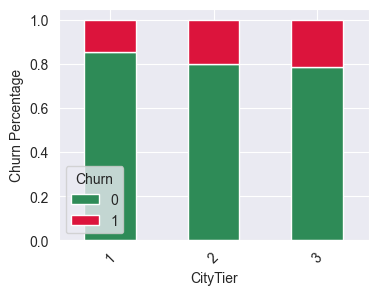

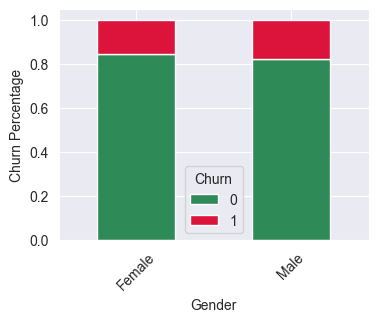

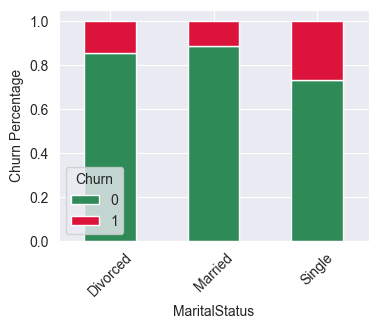

In [10]:
stack_plot(df, group="CityTier", target="Churn")
stack_plot(df, group="Gender", target="Churn")
stack_plot(df, group="MaritalStatus", target="Churn")

From the plots:
- Tier 1 cities are least likely to churn. Tier 2 and 3 cities are more likely. Cost could be the reason.
- Gender solely does not contribute much to the churn prediction.
- Single people has the highest tendency to churn. Married people are least likely.

In [11]:
df[(df.MaritalStatus == "Married") & (df.Gender == "Male")].Churn.value_counts()

Churn
0    1614
1     232
Name: count, dtype: int64

In [12]:
df[(df.MaritalStatus == "Divorced") & (df.Gender == "Female")].Churn.value_counts()

Churn
0    300
1     48
Name: count, dtype: int64

In [13]:
df[(df.MaritalStatus == "Single") & (df.Gender == "Female")].Churn.value_counts()

Churn
0    570
1    188
Name: count, dtype: int64

In [14]:
df[(df.MaritalStatus == "Single") & (df.Gender == "Male")].Churn.value_counts()

Churn
0    746
1    292
Name: count, dtype: int64

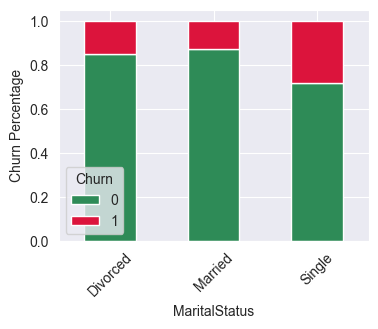

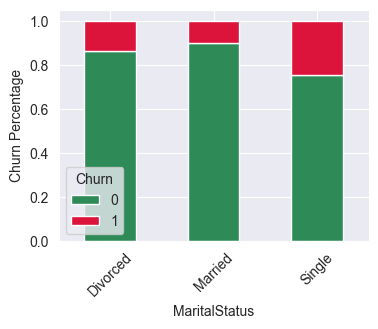

In [15]:
stack_plot(df[df.Gender == "Male"], group="MaritalStatus", target="Churn")
stack_plot(df[df.Gender == "Female"], group="MaritalStatus", target="Churn")

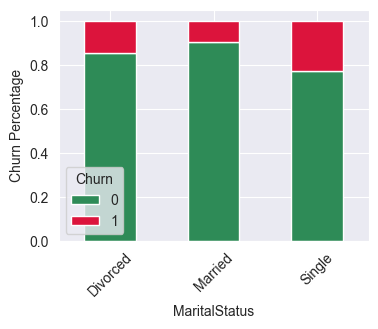

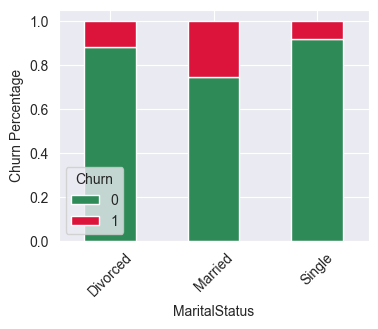

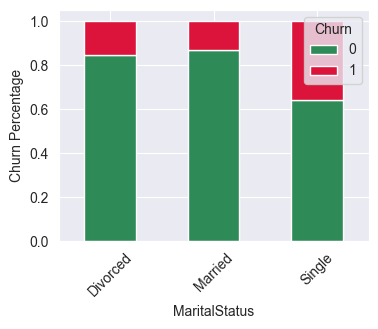

In [16]:
stack_plot(df[df.CityTier == 1], group="MaritalStatus", target="Churn")
stack_plot(df[df.CityTier == 2], group="MaritalStatus", target="Churn")
stack_plot(df[df.CityTier == 3], group="MaritalStatus", target="Churn")

From analysis:
- Churn tendency is similar across different marital statuses for Male and Female both.
- Across different tier cities, Divorced people are similar in churn trend, while singles from tier-3 cities are more prone to churn.

#### Tenure

In [17]:
df.Tenure.isna().value_counts()

Tenure
False    5366
True      264
Name: count, dtype: int64

In [18]:
null_tenure = df[df.Tenure.isna()]
null_tenure.head(10)

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
1,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
6,1,NaN,Phone,3,11.0,Cash on Delivery,Male,2.0,3,Laptop & Accessory,2,Divorced,4,0,14.0,0.0,1.0,0.0,120.86
7,1,NaN,Phone,1,6.0,CC,Male,3.0,3,Mobile,2,Divorced,3,1,16.0,2.0,2.0,0.0,122.93
9,1,NaN,Phone,1,31.0,Debit Card,Male,2.0,5,Mobile,3,Single,2,0,12.0,1.0,1.0,1.0,122.93
15,1,NaN,Phone,2,12.0,UPI,Male,3.0,3,Mobile,5,Married,5,1,22.0,1.0,1.0,2.0,120.73
22,1,NaN,Mobile Phone,3,28.0,E wallet,Male,2.0,3,Mobile Phone,3,Single,2,1,19.0,0.0,1.0,0.0,116.75
27,0,NaN,Phone,3,12.0,E wallet,Male,2.0,3,Laptop & Accessory,3,Divorced,3,1,20.0,0.0,4.0,5.0,123.06
34,0,NaN,Computer,3,8.0,E wallet,Female,3.0,3,Mobile,3,Divorced,7,0,18.0,1.0,1.0,2.0,122.31
36,0,NaN,Computer,1,15.0,CC,Male,2.0,3,Mobile,4,Married,7,0,18.0,0.0,2.0,2.0,120.24


- The null Tenures could be for customers who didn't stay logged enough to have a Tenure.
- But most of null Tenures have non-zero DaySinceLastOrder, HourSpendOnApp, OrderAmountHikeFromlastYear and high cashback amounts.
- So, it's likely a case of MAR (Missing At Random).

We will perform Multiple Imputation to predict the null values using other non-null features.

In [19]:
df.Tenure.describe()

count    5366.000000
mean       10.189899
std         8.557241
min         0.000000
25%         2.000000
50%         9.000000
75%        16.000000
max        61.000000
Name: Tenure, dtype: float64

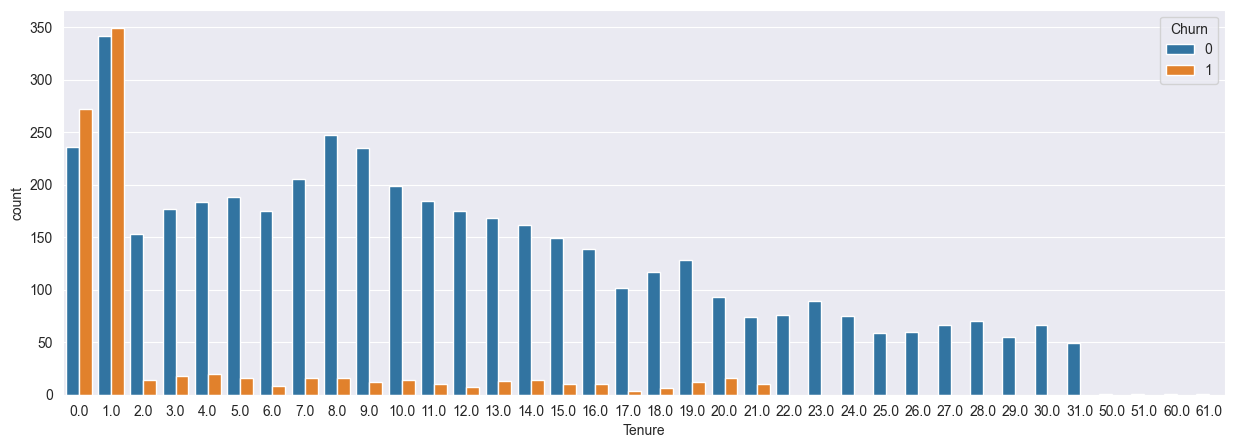

In [20]:
plt.figure(figsize=(15, 5))
sns.countplot(x="Tenure", hue="Churn", data=df)
plt.show()

Analysis:
- Tenure is given in months. Most of the churns happen in the early months.

Converting Tenure in years to reduce complexity

In [21]:
df["Tenure_group"] = df.Tenure.apply(lambda x: (x // 12) + 1)

In [22]:
df["Tenure_group"].value_counts()

Tenure_group
1.0    3288
2.0    1574
3.0     500
5.0       2
6.0       2
Name: count, dtype: int64

<Axes: xlabel='Tenure_group', ylabel='count'>

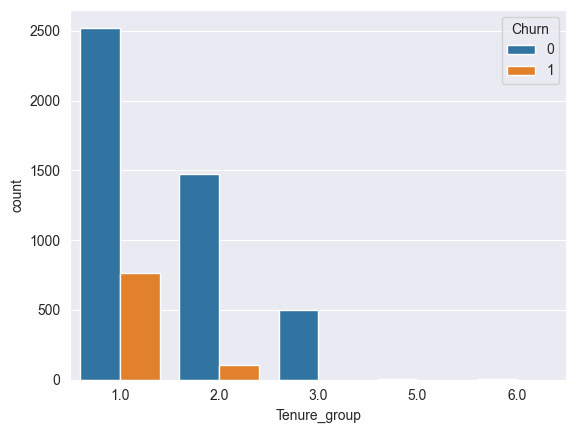

In [23]:
sns.countplot(x="Tenure_group", hue="Churn", data=df)

#### PreferredLoginDevice, PreferredPaymentMode, PreferedOrderCat, NumberOfDeviceRegistered, NumberOfAddress

In [24]:
for c in [
    "PreferredLoginDevice",
    "PreferredPaymentMode",
    "PreferedOrderCat",
    "NumberOfDeviceRegistered",
    "NumberOfAddress",
]:
    print(c)
    print(df[c].unique())
    print("-" * 50)

PreferredLoginDevice
['Mobile Phone' 'Phone' 'Computer']
--------------------------------------------------
PreferredPaymentMode
['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']
--------------------------------------------------
PreferedOrderCat
['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']
--------------------------------------------------
NumberOfDeviceRegistered
[3 4 5 2 1 6]
--------------------------------------------------
NumberOfAddress
[ 9  7  6  8  3  2  4 10  1  5 19 21 11 20 22]
--------------------------------------------------


In [25]:
df.PreferredLoginDevice = df.PreferredLoginDevice.replace({"Mobile Phone": "Phone"})
df.PreferredPaymentMode = df.PreferredPaymentMode.replace(
    {"Cash on Delivery": "COD", "CC": "Credit Card"}
)
df.PreferedOrderCat = df.PreferedOrderCat.replace({"Mobile Phone": "Mobile"})

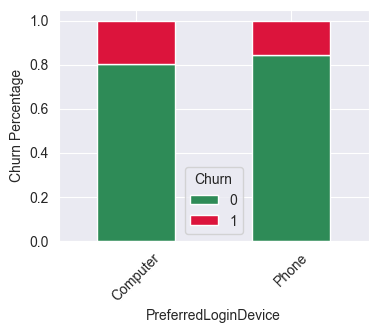

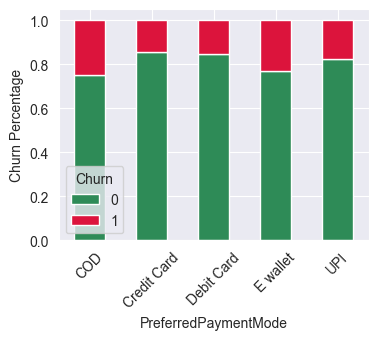

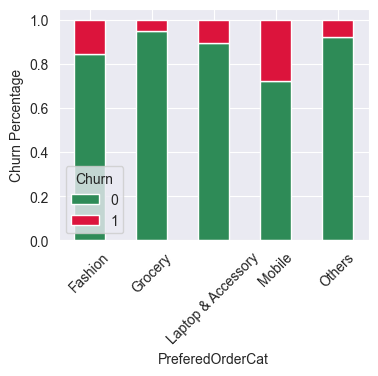

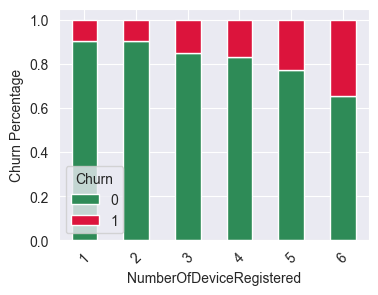

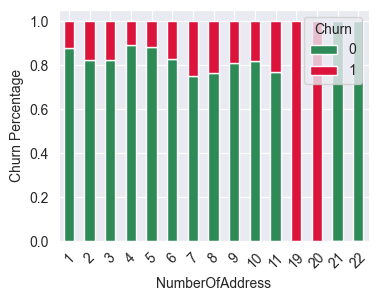

In [26]:
stack_plot(df, "PreferredLoginDevice", "Churn")
stack_plot(df, "PreferredPaymentMode", "Churn")
stack_plot(df, "PreferedOrderCat", "Churn")
stack_plot(df, "NumberOfDeviceRegistered", "Churn")
stack_plot(df, "NumberOfAddress", "Churn")

Analysis:
- Computeras login device shows somewhat higher churn tendency.
- Payment modes have different churn tendencies. COD and E Wallet methods are most likely to churn.
- Grocery item buyers are least likely to churn, Customers of fashion items and mobiles are most likely. Customers of costly items are more churn-prone.
- The customers with more number of devices registered are more likely to churn.
- Churn ratio increases with more number of addresses. Though, high number of addresses belong to a very few customers.

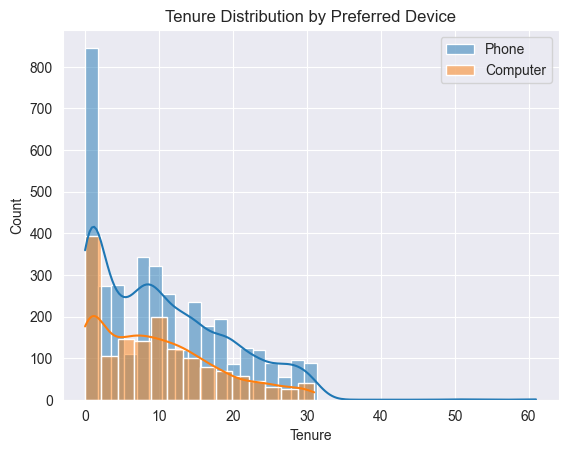

In [27]:
sns.histplot(
    df.Tenure[df.PreferredLoginDevice == "Phone"], kde=True, alpha=0.5, label="Phone"
)
sns.histplot(
    df.Tenure[df.PreferredLoginDevice == "Computer"],
    kde=True,
    alpha=0.5,
    label="Computer",
)
plt.title("Tenure Distribution by Preferred Device")
plt.legend()
plt.show()

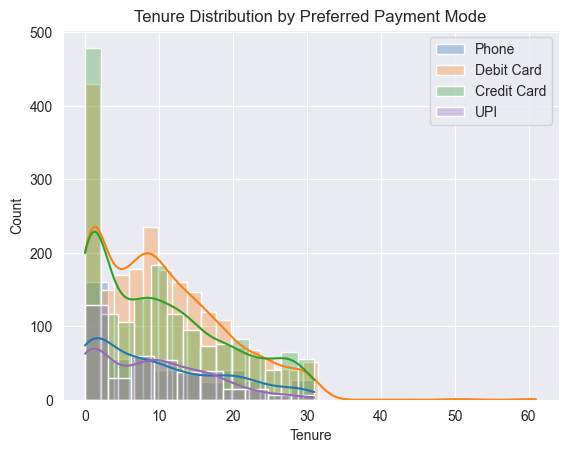

In [28]:
sns.histplot(
    df.Tenure[df.PreferredPaymentMode == "COD"], kde=True, alpha=0.3, label="Phone"
)
sns.histplot(
    df.Tenure[df.PreferredPaymentMode == "Debit Card"],
    kde=True,
    alpha=0.3,
    label="Debit Card",
)
sns.histplot(
    df.Tenure[df.PreferredPaymentMode == "Credit Card"],
    kde=True,
    alpha=0.3,
    label="Credit Card",
)
sns.histplot(
    df.Tenure[df.PreferredPaymentMode == "E Wallet"],
    kde=True,
    alpha=0.3,
    label="E Wallet",
)
sns.histplot(
    df.Tenure[df.PreferredPaymentMode == "UPI"], kde=True, alpha=0.3, label="UPI"
)
plt.title("Tenure Distribution by Preferred Payment Mode")
plt.legend()
plt.show()

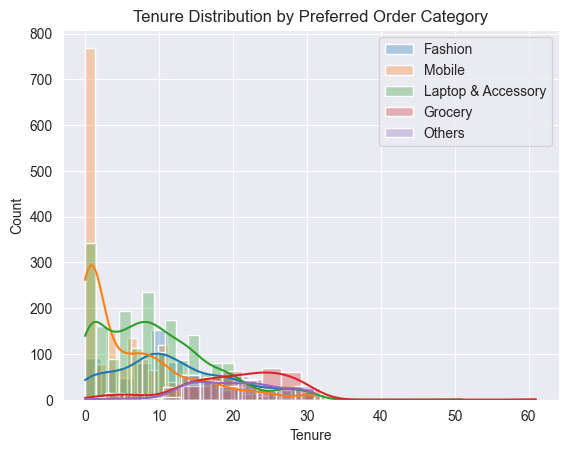

In [29]:
sns.histplot(
    df.Tenure[df.PreferedOrderCat == "Fashion"], kde=True, alpha=0.3, label="Fashion"
)
sns.histplot(
    df.Tenure[df.PreferedOrderCat == "Mobile"], kde=True, alpha=0.3, label="Mobile"
)
sns.histplot(
    df.Tenure[df.PreferedOrderCat == "Laptop & Accessory"],
    kde=True,
    alpha=0.3,
    label="Laptop & Accessory",
)
sns.histplot(
    df.Tenure[df.PreferedOrderCat == "Grocery"], kde=True, alpha=0.3, label="Grocery"
)
sns.histplot(
    df.Tenure[df.PreferedOrderCat == "Others"], kde=True, alpha=0.3, label="Others"
)
plt.title("Tenure Distribution by Preferred Order Category")
plt.legend()
plt.show()

The customers with lowest Tenures are the customers with 'Mobile' as preferred product category.

#### Complain

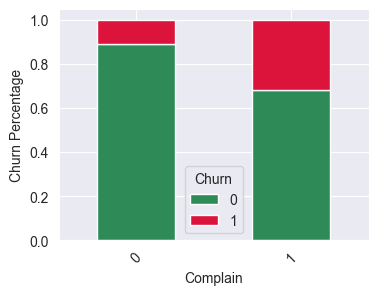

In [30]:
stack_plot(df, "Complain", "Churn")

In [31]:
df[["Complain", "Churn"]].groupby(["Complain"]).agg(["mean"])

,Churn
,mean
Complain,
0,0.109290
1,0.316708


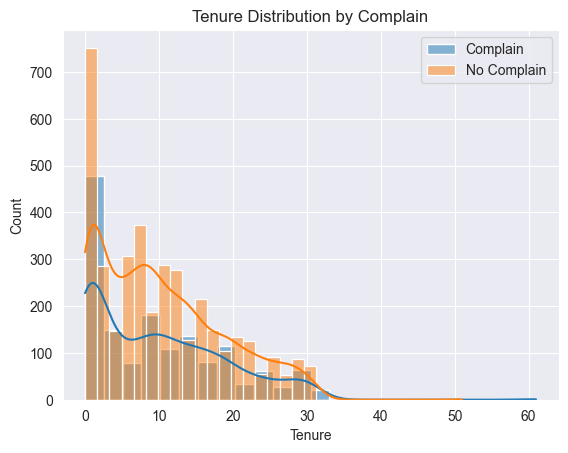

In [32]:
sns.histplot(df.Tenure[df.Complain == 1], kde=True, alpha=0.5, label="Complain")
sns.histplot(df.Tenure[df.Complain == 0], kde=True, alpha=0.5, label="No Complain")
plt.title("Tenure Distribution by Complain")
plt.legend()
plt.show()

Users with Complain tend to Churn at a very higher rate. There can be two possibilities.
- They filed complaint before they are about to churn.
- Their complaints were not paide attention to, and they eventually left.


If the former is true, then it should not be used as a feature as it is directly proxying the target.

### Continuous Values Analysis

In [33]:
churn = df[df.Churn == 1]
no_churn = df[df.Churn == 0]

#### WarehouseToHome

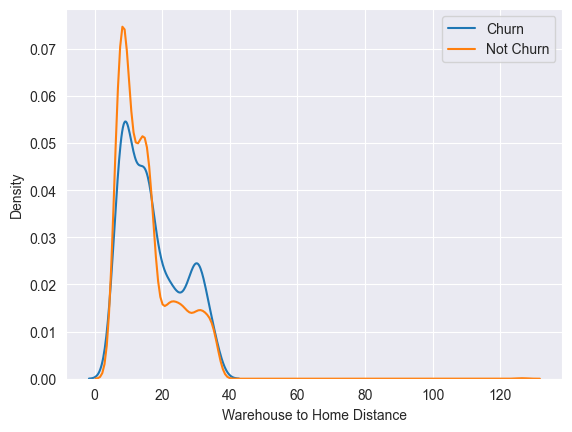

In [34]:
sns.kdeplot(churn.WarehouseToHome, label="Churn")
sns.kdeplot(no_churn.WarehouseToHome, label="Not Churn")
plt.xlabel("Warehouse to Home Distance")
plt.legend()

Churn and Loyal customers's distance from warehouse to home have similar shape distribution. Churn customers have lower peaks.

In [35]:
df.WarehouseToHome.isna().value_counts()

WarehouseToHome
False    5379
True      251
Name: count, dtype: int64

In [36]:
null_warehouse = df[df.WarehouseToHome.isna()]
null_warehouse.head(10)

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Tenure_group
28,0,18.0,Phone,1,NaN,Debit Card,Male,2.0,3,Laptop & Accessory,4,Married,9,0,18.0,1.0,1.0,15.0,123.48,2.0
35,0,0.0,Phone,1,NaN,Credit Card,Male,3.0,3,Mobile,2,Divorced,2,0,24.0,0.0,2.0,2.0,123.23,1.0
39,0,0.0,Computer,1,NaN,Credit Card,Male,3.0,4,Mobile,3,Married,2,1,15.0,0.0,1.0,1.0,125.66,1.0
41,0,14.0,Phone,1,NaN,Debit Card,Male,2.0,3,Mobile,3,Married,5,0,12.0,1.0,1.0,8.0,124.51,2.0
46,1,0.0,Computer,3,NaN,COD,Female,3.0,5,Mobile,5,Single,1,0,21.0,1.0,1.0,0.0,123.25,1.0
51,0,6.0,Phone,1,NaN,Debit Card,Male,2.0,3,Mobile,2,Single,1,0,14.0,0.0,1.0,2.0,125.00,1.0
81,0,0.0,Phone,1,NaN,Debit Card,Male,2.0,2,Mobile,4,Married,2,1,16.0,0.0,2.0,2.0,123.28,1.0
89,1,0.0,Phone,1,NaN,COD,Female,2.0,3,Mobile,5,Single,6,1,11.0,1.0,1.0,4.0,126.57,1.0
96,0,6.0,Phone,1,NaN,Credit Card,Female,2.0,4,Mobile,4,Divorced,7,0,21.0,0.0,1.0,1.0,126.22,1.0
104,1,0.0,Phone,1,NaN,Credit Card,Male,2.0,4,Mobile,2,Single,2,1,13.0,0.0,1.0,1.0,123.89,1.0


<Axes: xlabel='Tenure', ylabel='Count'>

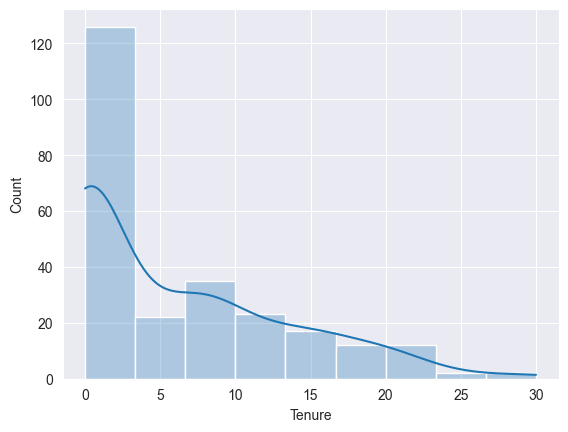

In [37]:
sns.histplot(null_warehouse["Tenure"], kde=True, alpha=0.3)

In [ ]:
null_warehouse[null_warehouse.Churn == 1].head(10)

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Tenure_group
46,1,0.0,Computer,3,NaN,COD,Female,3.0,5,Mobile,5,Single,1,0,21.0,1.0,1.0,0.0,123.25,1.0
89,1,0.0,Phone,1,NaN,COD,Female,2.0,3,Mobile,5,Single,6,1,11.0,1.0,1.0,4.0,126.57,1.0
104,1,0.0,Phone,1,NaN,Credit Card,Male,2.0,4,Mobile,2,Single,2,1,13.0,0.0,1.0,1.0,123.89,1.0
109,1,0.0,Phone,1,NaN,Credit Card,Male,2.0,3,Mobile,2,Divorced,6,1,13.0,0.0,1.0,4.0,124.36,1.0
163,1,0.0,Phone,1,NaN,Credit Card,Male,2.0,3,Mobile,4,Married,3,1,13.0,1.0,1.0,2.0,123.73,1.0
290,1,0.0,Computer,3,NaN,E wallet,Female,2.0,5,Mobile,3,Married,1,0,16.0,1.0,1.0,0.0,123.51,1.0
296,1,0.0,Phone,1,NaN,COD,Female,3.0,4,Mobile,4,Divorced,6,0,16.0,0.0,1.0,1.0,125.46,1.0
297,1,0.0,Phone,2,NaN,COD,Male,2.0,4,Mobile,2,Single,2,0,12.0,1.0,1.0,0.0,125.64,1.0
338,1,0.0,Phone,1,NaN,COD,Male,3.0,5,Mobile,2,Single,2,1,18.0,1.0,1.0,0.0,123.40,1.0
464,1,0.0,Phone,1,NaN,Debit Card,Female,2.0,4,Mobile,5,Divorced,2,1,11.0,0.0,1.0,0.0,123.19,1.0


Some values of WarehouseToHome are missing. Most of them are having 1 month tenure. But there are no significant trends of missingness. Likely MAR.

#### HourSpendOnApp

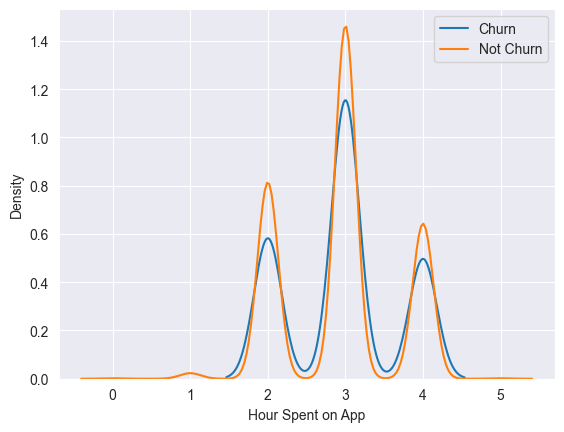

In [39]:
sns.kdeplot(churn.HourSpendOnApp, label="Churn")
sns.kdeplot(no_churn.HourSpendOnApp, label="Not Churn")
plt.xlabel("Hour Spent on App")
plt.legend()

Churns and Loyal customers have similar shape distributions of HourSpendOnApp, loyal customers having higher peaks than churns.

In [40]:
df.HourSpendOnApp.isna().value_counts()

HourSpendOnApp
False    5375
True      255
Name: count, dtype: int64

In [41]:
null_hourspend = df[df.HourSpendOnApp.isna()]
null_hourspend[null_hourspend.Churn == 1].head(10)

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Tenure_group
4,1,0.0,Phone,1,12.0,Credit Card,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60,1.0
8,1,13.0,Phone,3,9.0,E wallet,Male,NaN,4,Mobile,3,Divorced,2,1,14.0,0.0,1.0,2.0,126.83,2.0
16,1,0.0,Computer,1,12.0,Debit Card,Female,NaN,4,Mobile,2,Single,2,1,18.0,1.0,1.0,0.0,129.26,1.0
57,1,4.0,Phone,3,26.0,E wallet,Female,NaN,3,Mobile,4,Single,2,1,22.0,0.0,1.0,2.0,131.40,1.0
111,1,0.0,Phone,1,8.0,Debit Card,Female,NaN,3,Mobile,5,Divorced,8,0,20.0,1.0,1.0,7.0,127.07,1.0
161,1,7.0,Computer,1,30.0,Debit Card,Male,NaN,3,Mobile,3,Married,4,1,22.0,0.0,1.0,0.0,131.61,1.0
238,1,0.0,Phone,3,11.0,E wallet,Female,NaN,3,Mobile,3,Single,2,1,13.0,1.0,1.0,0.0,128.51,1.0
245,1,0.0,Phone,3,18.0,Debit Card,Female,NaN,2,Mobile,4,Single,2,0,15.0,0.0,1.0,0.0,127.16,1.0
257,1,0.0,Computer,1,9.0,COD,Male,NaN,3,Mobile,5,Single,1,0,22.0,0.0,1.0,4.0,131.02,1.0
328,1,0.0,Computer,2,23.0,Debit Card,Female,NaN,3,Mobile,3,Married,1,1,11.0,0.0,1.0,0.0,127.41,1.0


Some values of HourSpendOnApp are missing. Most of them are having 1 month tenure. But there are no significant trends of missingness. Likely MAR.

####  OrderAmountHikeFromlastYear

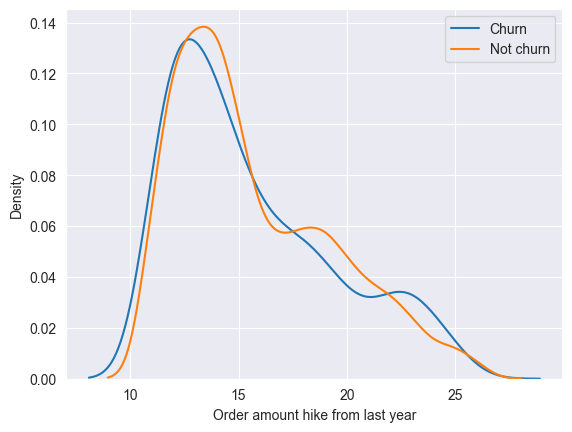

In [42]:
sns.kdeplot(churn.OrderAmountHikeFromlastYear, label="Churn")
sns.kdeplot(no_churn.OrderAmountHikeFromlastYear, label="Not churn")
plt.xlabel("Order amount hike from last year")
plt.legend()

Both churn and loyal customers have similar distributions of order amount hike.

In [43]:
df.OrderAmountHikeFromlastYear.isna().value_counts()

OrderAmountHikeFromlastYear
False    5365
True      265
Name: count, dtype: int64

In [44]:
df[df.OrderAmountHikeFromlastYear.isna()].head(10)

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Tenure_group
10,1,4.0,Phone,1,18.0,COD,Female,2.0,3,Others,3,Divorced,2,0,NaN,9.0,15.0,8.0,295.45,1.0
40,0,23.0,Phone,1,17.0,Debit Card,Female,2.0,3,Others,4,Single,4,0,NaN,2.0,4.0,4.0,299.26,2.0
65,0,25.0,Phone,1,6.0,Debit Card,Male,3.0,4,Others,3,Divorced,1,0,NaN,1.0,11.0,9.0,299.99,3.0
106,0,15.0,Phone,1,10.0,COD,Male,2.0,3,Others,2,Divorced,2,0,NaN,0.0,11.0,15.0,292.32,2.0
108,0,23.0,Phone,3,6.0,Credit Card,Female,3.0,3,Others,2,Married,4,0,NaN,1.0,1.0,6.0,295.17,2.0
119,0,18.0,Phone,1,6.0,UPI,Male,3.0,2,Others,2,Divorced,1,0,NaN,1.0,1.0,7.0,292.02,2.0
132,0,13.0,Phone,1,8.0,Credit Card,Male,2.0,3,Others,3,Married,1,0,NaN,0.0,3.0,9.0,294.36,2.0
201,0,12.0,Computer,1,5.0,Credit Card,Male,2.0,4,Others,2,Divorced,2,0,NaN,9.0,13.0,3.0,292.72,2.0
267,0,27.0,Phone,1,11.0,Credit Card,Male,2.0,3,Others,5,Divorced,5,0,NaN,1.0,1.0,2.0,294.06,3.0
286,0,30.0,Phone,1,13.0,Debit Card,Female,2.0,3,Others,5,Divorced,6,0,NaN,0.0,11.0,10.0,295.66,3.0


Some of the values are empty, but there is no apparent trend of missingness. Likely MAR (Missing At Random).

#### CouponUsed

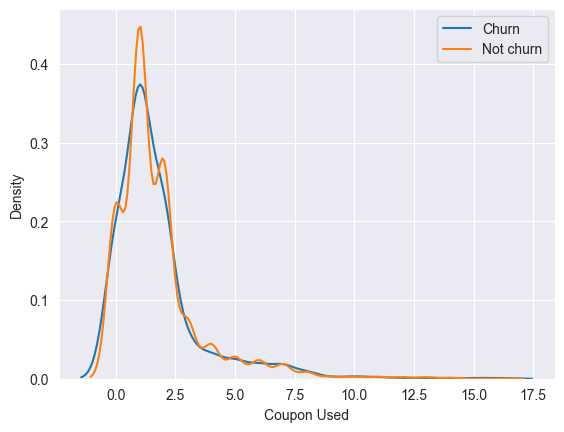

In [45]:
sns.kdeplot(churn.CouponUsed, label="Churn")
sns.kdeplot(no_churn.CouponUsed, label="Not churn")
plt.xlabel("Coupon Used")
plt.legend()

Similar distribution of Coupon use for both Churn and Loyal customers.

In [46]:
df.CouponUsed.isna().value_counts()

CouponUsed
False    5374
True      256
Name: count, dtype: int64

In [ ]:
df[df.CouponUsed.isna()].head(10)

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Tenure_group
61,0,13.0,Phone,1,10.0,Credit Card,Female,2.0,3,Others,3,Divorced,2,0,14.0,NaN,9.0,9.0,290.33,2.0
62,0,28.0,Phone,1,20.0,Credit Card,Male,3.0,2,Others,4,Single,9,0,11.0,NaN,2.0,15.0,287.22,3.0
69,0,18.0,Computer,1,8.0,Credit Card,Male,3.0,4,Grocery,2,Divorced,10,0,23.0,NaN,11.0,8.0,267.92,2.0
112,0,25.0,Computer,3,8.0,Debit Card,Male,3.0,4,Others,3,Single,2,1,18.0,NaN,15.0,12.0,290.68,3.0
138,0,19.0,Phone,3,8.0,COD,Female,3.0,5,Grocery,4,Divorced,4,1,12.0,NaN,7.0,7.0,268.72,2.0
145,0,28.0,Phone,1,6.0,Credit Card,Male,2.0,3,Others,5,Single,1,1,14.0,NaN,4.0,13.0,290.45,3.0
154,0,23.0,Phone,1,10.0,Debit Card,Male,3.0,3,Others,4,Married,4,0,14.0,NaN,1.0,6.0,291.44,2.0
155,0,26.0,Phone,1,9.0,Credit Card,Male,2.0,3,Grocery,3,Divorced,4,1,16.0,NaN,1.0,3.0,275.84,3.0
165,0,22.0,Computer,1,16.0,Debit Card,Female,2.0,3,Others,5,Single,10,1,11.0,NaN,1.0,2.0,286.65,2.0
189,0,12.0,Phone,1,16.0,Credit Card,Male,2.0,3,Grocery,5,Divorced,2,1,14.0,NaN,11.0,10.0,270.68,2.0


In [48]:
df.CashbackAmount[df.CouponUsed.isna()].describe()

count    256.000000
mean     276.211914
std       10.187445
min      260.910000
25%      267.400000
50%      275.160000
75%      286.342500
max      291.900000
Name: CashbackAmount, dtype: float64

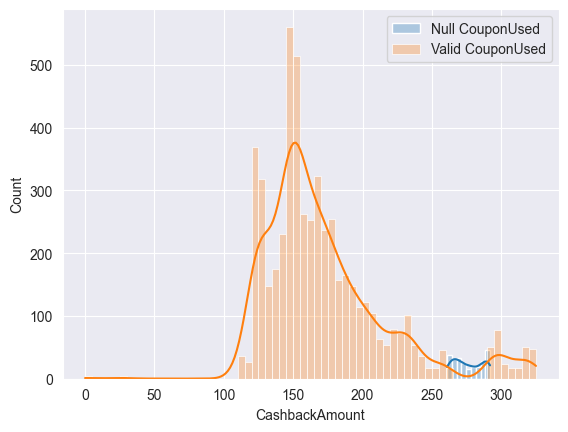

In [49]:
sns.histplot(
    df.CashbackAmount[df.CouponUsed.isna()],
    kde=True,
    alpha=0.3,
    label="Null CouponUsed",
)
sns.histplot(
    df.CashbackAmount[df.CouponUsed.isna() == False],
    kde=True,
    alpha=0.3,
    label="Valid CouponUsed",
)
plt.legend()

A small part of the dataset has missing CouponValues. Likely MAR.

#### OrderCount

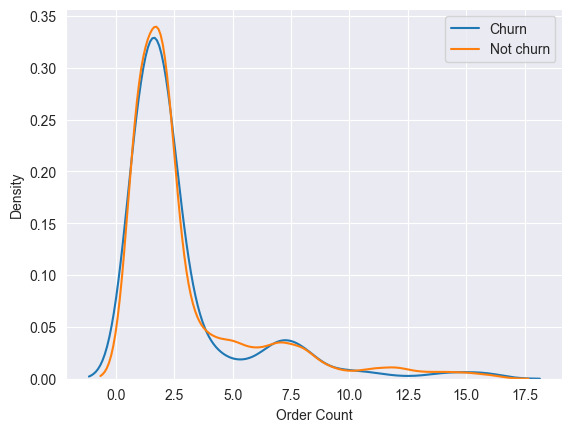

In [50]:
sns.kdeplot(churn.OrderCount, label="Churn")
sns.kdeplot(no_churn.OrderCount, label="Not churn")
plt.xlabel("Order Count")
plt.legend()

Similar distribution of OrderCount for both Churn and Loyal customers.

In [51]:
df.OrderCount.isna().value_counts()

OrderCount
False    5372
True      258
Name: count, dtype: int64

In [52]:
df[df.OrderCount.isna()].head(10)

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Tenure_group
64,0,24.0,Phone,1,9.0,Credit Card,Female,3.0,3,Grocery,4,Single,4,0,18.0,0.0,NaN,0.0,237.34,3.0
90,0,14.0,Phone,3,12.0,Debit Card,Female,3.0,3,Fashion,2,Single,4,1,18.0,0.0,NaN,0.0,235.91,2.0
110,0,16.0,Phone,3,22.0,E wallet,Female,3.0,3,Grocery,2,Divorced,6,1,22.0,0.0,NaN,9.0,260.64,2.0
120,0,4.0,Computer,1,9.0,Credit Card,Male,3.0,3,Fashion,3,Married,10,0,12.0,1.0,NaN,2.0,236.75,1.0
143,0,18.0,Phone,1,26.0,Credit Card,Male,3.0,3,Grocery,2,Divorced,1,1,14.0,0.0,NaN,10.0,234.96,2.0
150,0,10.0,Computer,1,6.0,Credit Card,Female,0.0,3,Fashion,2,Married,3,1,18.0,0.0,NaN,2.0,236.03,1.0
170,0,15.0,Computer,3,32.0,E wallet,Female,3.0,3,Grocery,4,Divorced,6,0,14.0,2.0,NaN,8.0,235.25,2.0
175,0,14.0,Phone,3,8.0,Debit Card,Male,2.0,3,Grocery,4,Single,2,0,19.0,1.0,NaN,4.0,260.15,2.0
191,0,22.0,Phone,1,6.0,COD,Female,2.0,4,Grocery,3,Single,8,1,12.0,1.0,NaN,7.0,239.64,2.0
223,0,15.0,Phone,1,29.0,Debit Card,Female,2.0,3,Grocery,2,Single,3,0,14.0,0.0,NaN,0.0,259.92,2.0


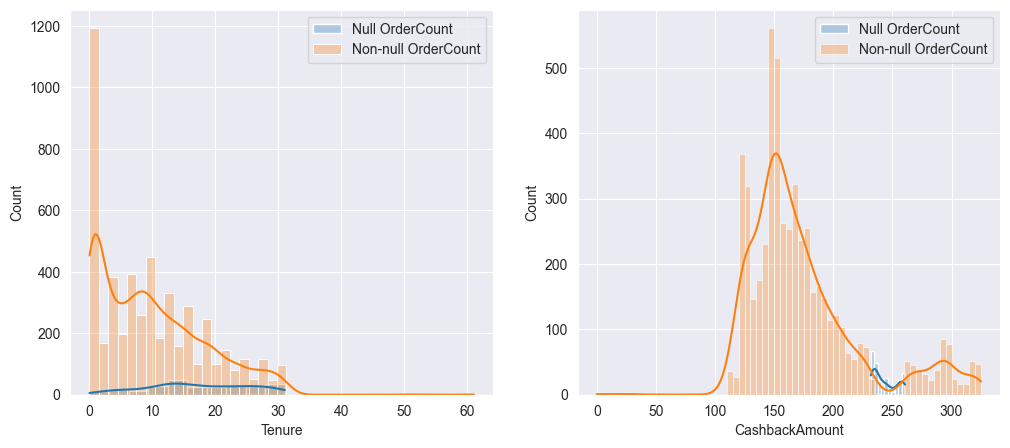

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(
    df.Tenure[df.OrderCount.isna()], kde=True, alpha=0.3, label="Null OrderCount"
)
sns.histplot(
    df.Tenure[df.OrderCount.isna() == False],
    kde=True,
    alpha=0.3,
    label="Non-null OrderCount",
)
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(
    df.CashbackAmount[df.OrderCount.isna()],
    kde=True,
    alpha=0.3,
    label="Null OrderCount",
)
sns.histplot(
    df.CashbackAmount[df.OrderCount.isna() == False],
    kde=True,
    alpha=0.3,
    label="Non-null OrderCount",
)
plt.legend()

Some values of OrderCount is missing, probably MAR.

#### DaySinceLastOrder

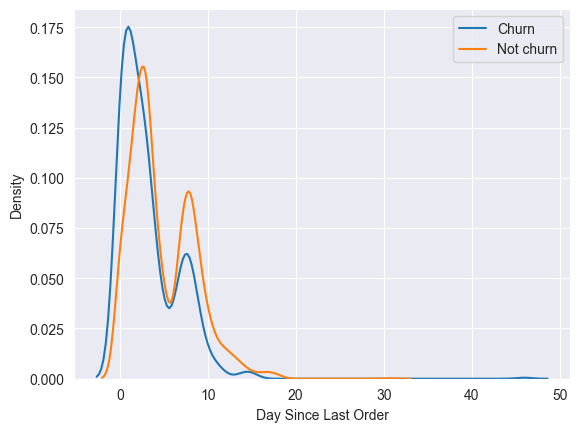

In [54]:
sns.kdeplot(churn.DaySinceLastOrder, label="Churn")
sns.kdeplot(no_churn.DaySinceLastOrder, label="Not churn")
plt.xlabel("Day Since Last Order")
plt.legend()

Both distributions have similar shape, though churn customers are shifted a bit left than loyal customers.

In [55]:
df.DaySinceLastOrder.isna().value_counts()

DaySinceLastOrder
False    5323
True      307
Name: count, dtype: int64

In [56]:
df[df.DaySinceLastOrder.isna()].head(10)

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Tenure_group
88,0,24.0,Phone,1,14.0,Debit Card,Male,2.0,4,Fashion,4,Divorced,6,0,16.0,1.0,4.0,NaN,224.90,3.0
97,0,10.0,Computer,1,17.0,UPI,Male,2.0,3,Fashion,2,Married,2,1,14.0,0.0,1.0,NaN,221.85,1.0
126,0,12.0,Computer,1,8.0,COD,Female,3.0,3,Fashion,3,Single,1,0,25.0,10.0,11.0,NaN,209.38,2.0
146,1,10.0,Computer,1,35.0,Debit Card,Male,2.0,3,Fashion,4,Divorced,2,1,12.0,5.0,9.0,NaN,218.49,1.0
151,0,2.0,Phone,1,28.0,Debit Card,Female,3.0,2,Fashion,4,Married,8,0,18.0,5.0,6.0,NaN,219.96,1.0
182,0,11.0,Phone,1,31.0,Debit Card,Female,2.0,4,Fashion,4,Divorced,4,0,17.0,1.0,1.0,NaN,220.61,1.0
188,0,6.0,Computer,1,11.0,Debit Card,Female,3.0,3,Fashion,4,Divorced,7,0,11.0,2.0,8.0,NaN,218.78,1.0
216,0,11.0,Phone,1,21.0,Debit Card,Male,3.0,4,Fashion,2,Married,1,1,14.0,1.0,2.0,NaN,215.10,1.0
227,0,21.0,Phone,3,35.0,Credit Card,Female,3.0,3,Fashion,3,Divorced,4,0,21.0,0.0,1.0,NaN,225.04,2.0
295,0,2.0,Phone,1,9.0,Credit Card,Male,3.0,4,Fashion,3,Divorced,2,0,18.0,1.0,1.0,NaN,219.35,1.0


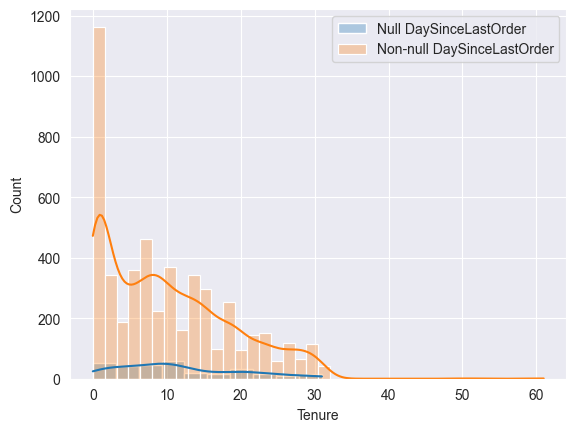

In [ ]:
sns.histplot(
    df.Tenure[df.DaySinceLastOrder.isna()],
    kde=True,
    alpha=0.3,
    label="Null DaySinceLastOrder",
)
sns.histplot(
    df.Tenure[df.DaySinceLastOrder.isna() == False],
    kde=True,
    alpha=0.3,
    label="Non-null DaySinceLastOrder",
)
plt.legend()

Some values are missing without any apparent tendency. Likely MAR.

#### CashbackAmount

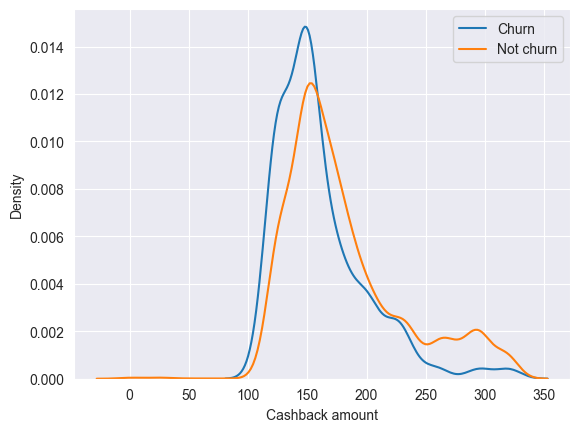

In [58]:
sns.kdeplot(churn.CashbackAmount, label="Churn")
sns.kdeplot(no_churn.CashbackAmount, label="Not churn")
plt.xlabel("Cashback amount")
plt.legend()

Churn customers have slightly lower mean of cashback amounts than loyal ones.

In [59]:
df.CashbackAmount.isna().value_counts()

CashbackAmount
False    5630
Name: count, dtype: int64

#### Correlation

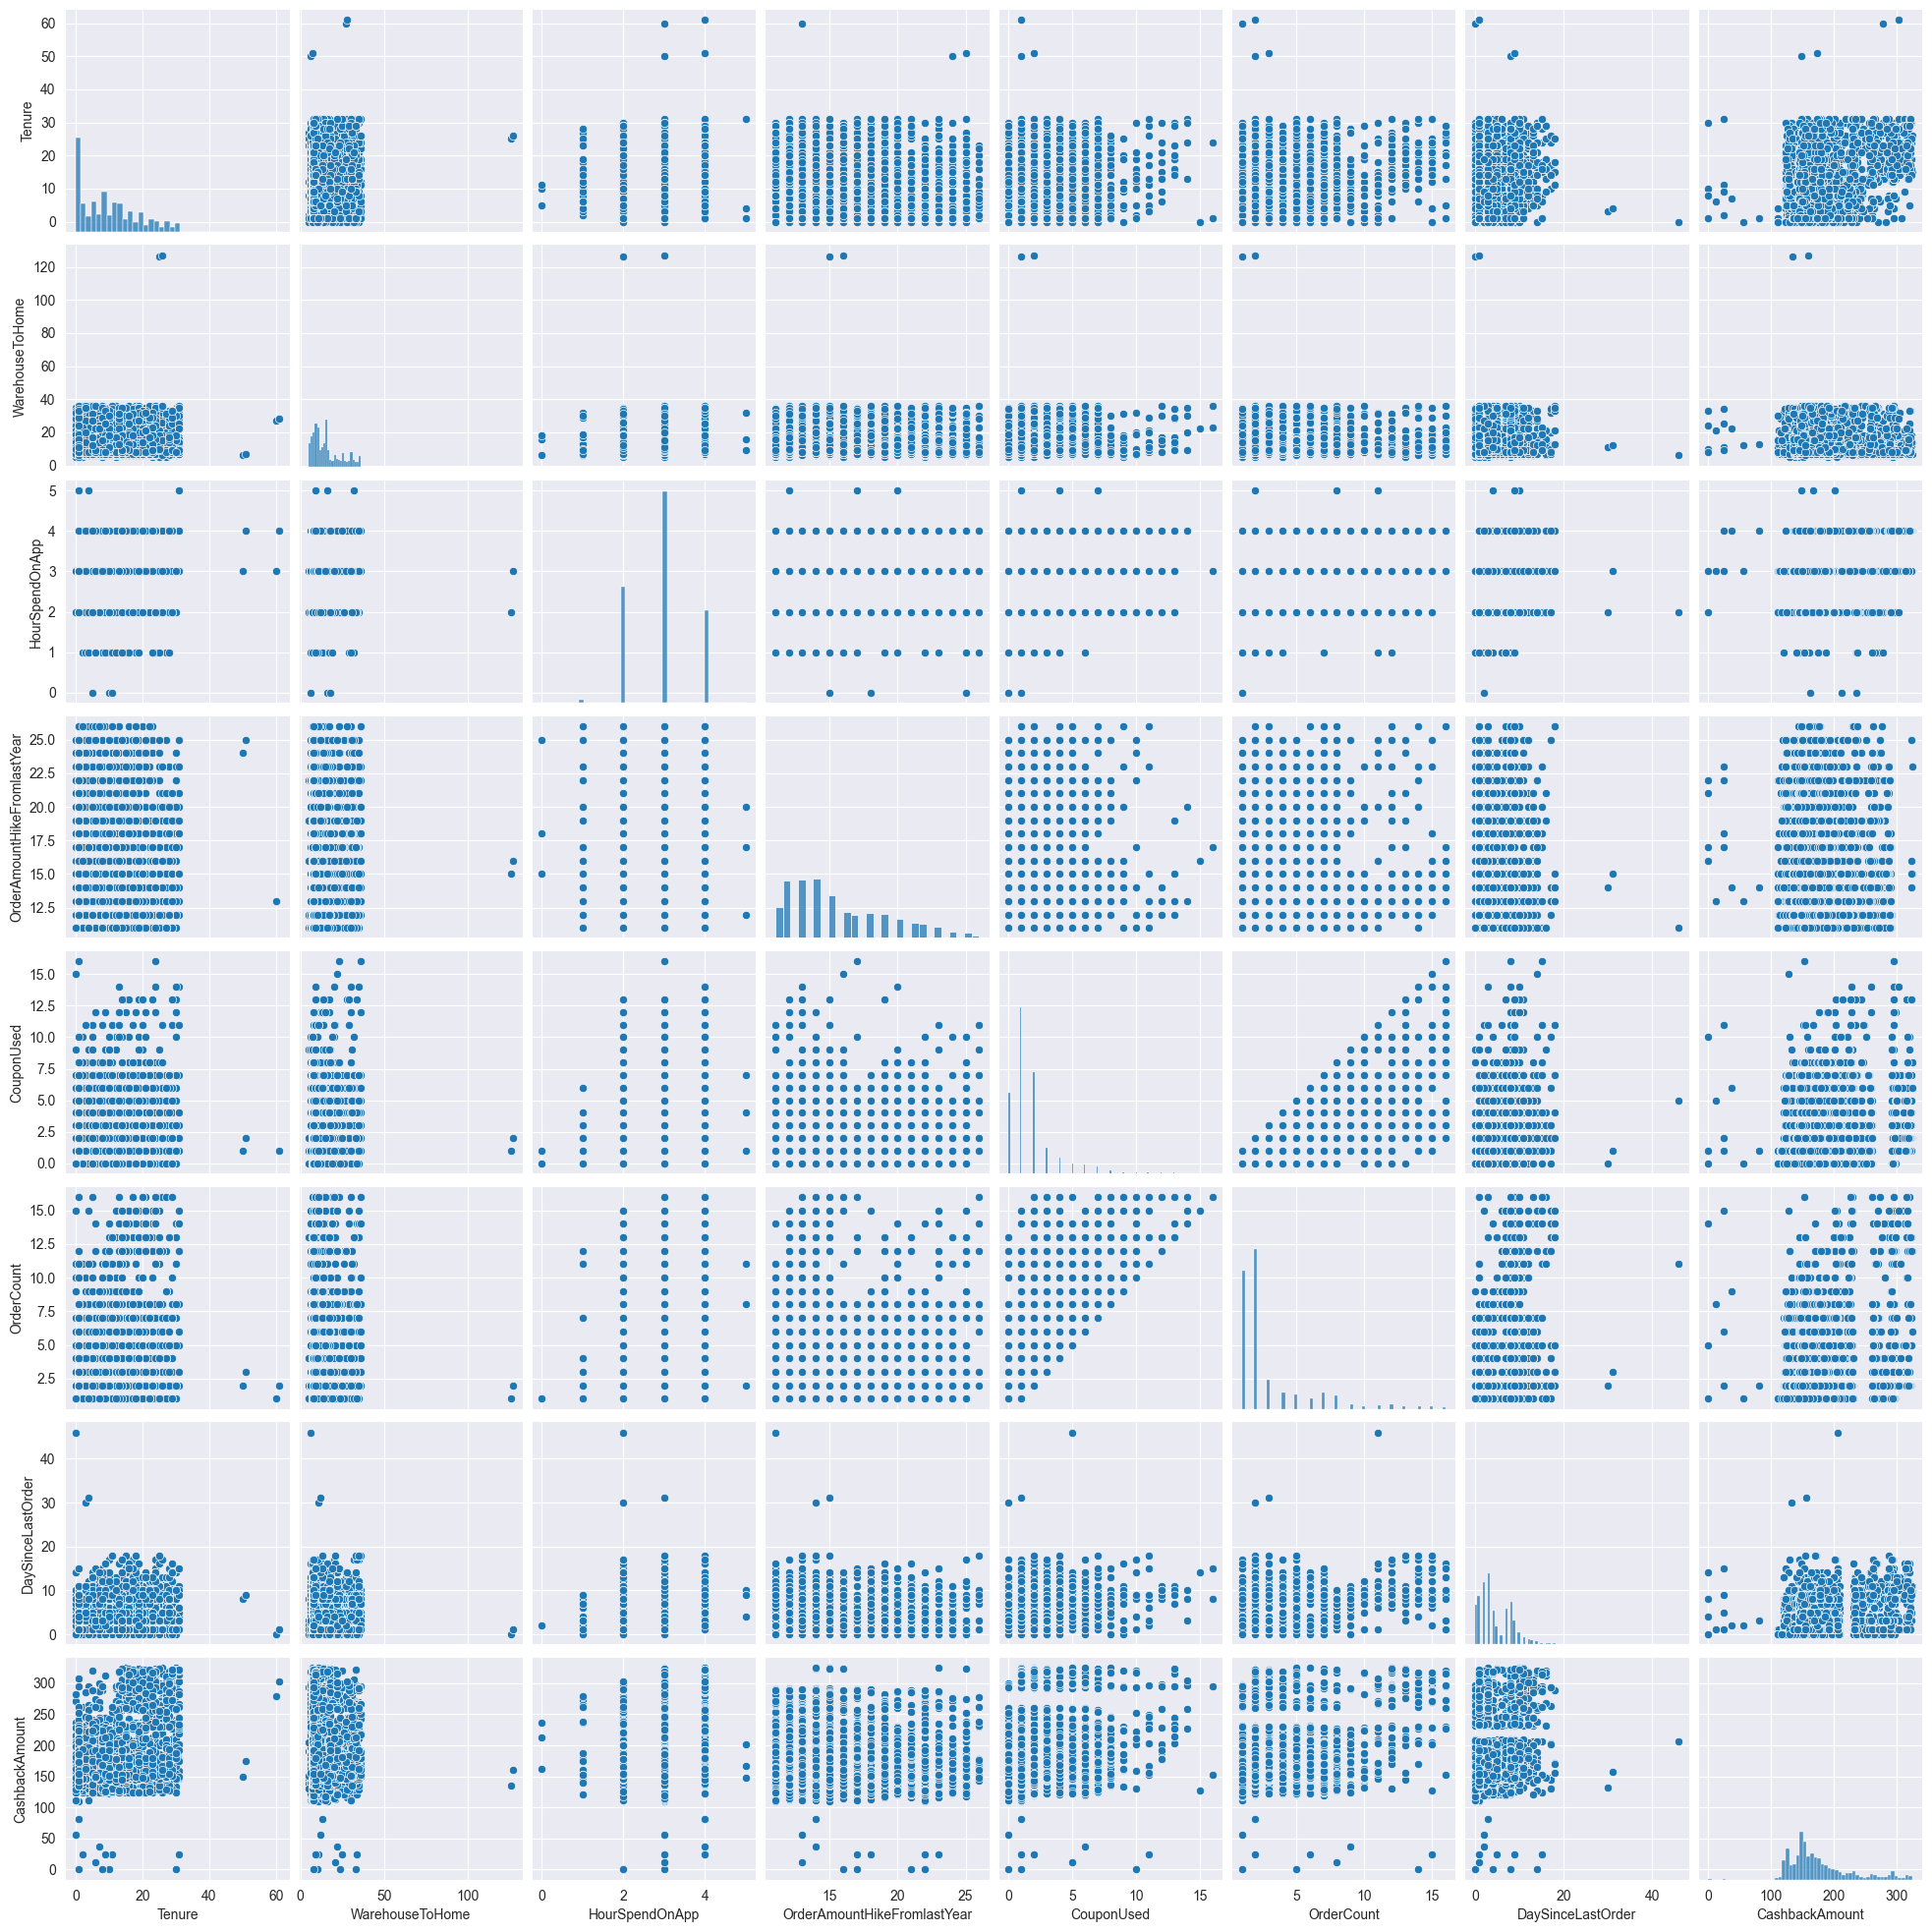

In [60]:
sns.pairplot(df[numerical_variables])

In [61]:
from scipy.stats import pearsonr

In [62]:
pearsonr(df.dropna()["Tenure"], df.dropna()["CashbackAmount"]).pvalue

np.float64(2.7477264642203142e-40)

In [63]:
print("Pearson Correlation:")
for in_i, i in enumerate(numerical_variables):
    for j in numerical_variables[in_i + 1 :]:
        pear = pearsonr(df.dropna()[i], df.dropna()[j])
        print(f"{i} X {j}: {round(pear.statistic, 4)}")
        print("-" * 20)

Pearson Correlation:
Tenure X WarehouseToHome: -0.0164
--------------------
Tenure X HourSpendOnApp: -0.0298
--------------------
Tenure X OrderAmountHikeFromlastYear: 0.0122
--------------------
Tenure X CouponUsed: 0.076
--------------------
Tenure X OrderCount: 0.1123
--------------------
Tenure X DaySinceLastOrder: 0.1189
--------------------
Tenure X CashbackAmount: 0.2139
--------------------
WarehouseToHome X HourSpendOnApp: 0.0527
--------------------
WarehouseToHome X OrderAmountHikeFromlastYear: 0.032
--------------------
WarehouseToHome X CouponUsed: -0.0143
--------------------
WarehouseToHome X OrderCount: 0.0088
--------------------
WarehouseToHome X DaySinceLastOrder: 0.0106
--------------------
WarehouseToHome X CashbackAmount: -0.0124
--------------------
HourSpendOnApp X OrderAmountHikeFromlastYear: 0.0968
--------------------
HourSpendOnApp X CouponUsed: 0.1602
--------------------
HourSpendOnApp X OrderCount: 0.0926
--------------------
HourSpendOnApp X DaySinceLast

(CouponUsed, OrderCount, DaySinceLastOrder) have high Pearson Correlations.

In [84]:
df["CouponUsed_x_OrderCount"] = df.CouponUsed * df.OrderCount
df["DaySinceLastOrder_x_CouponUsed"] = df.DaySinceLastOrder * df.CouponUsed
df["OrderCount_x_DaySincsLastOrder"] = df.DaySinceLastOrder * df.OrderCount

df["Tenure_x_CashbackAmount"] = df.Tenure * df.CashbackAmount
df["OrderCount_x_CashbackAmount"] = df.OrderCount * df.CashbackAmount
df["DaySinceLastOrder_x_CashbackAmount"] = df.DaySinceLastOrder * df.CashbackAmount

In [85]:
churn = df[df.Churn == 1]
no_churn = df[df.Churn == 0]

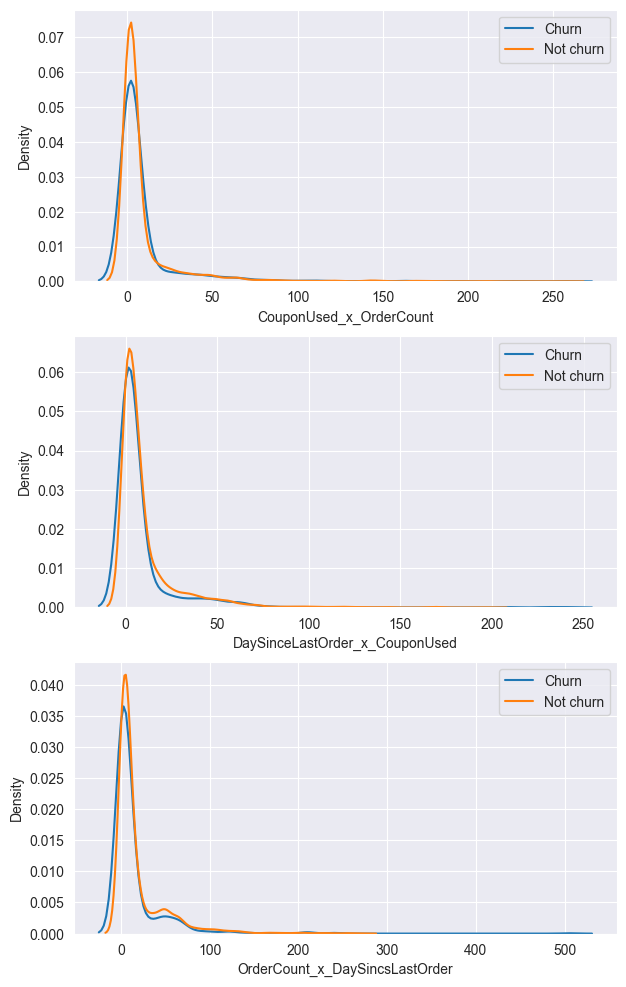

In [83]:
plt.figure(figsize=(7, 12))
plt.subplot(311)
sns.kdeplot(churn.CouponUsed_x_OrderCount, label="Churn")
sns.kdeplot(no_churn.CouponUsed_x_OrderCount, label="Not churn")
plt.xlabel("CouponUsed_x_OrderCount")
plt.legend()

plt.subplot(312)
sns.kdeplot(churn.DaySinceLastOrder_x_CouponUsed, label="Churn")
sns.kdeplot(no_churn.DaySinceLastOrder_x_CouponUsed, label="Not churn")
plt.xlabel("DaySinceLastOrder_x_CouponUsed")
plt.legend()

plt.subplot(313)
sns.kdeplot(churn.OrderCount_x_DaySincsLastOrder, label="Churn")
sns.kdeplot(no_churn.OrderCount_x_DaySincsLastOrder, label="Not churn")
plt.xlabel("OrderCount_x_DaySincsLastOrder")
plt.legend()

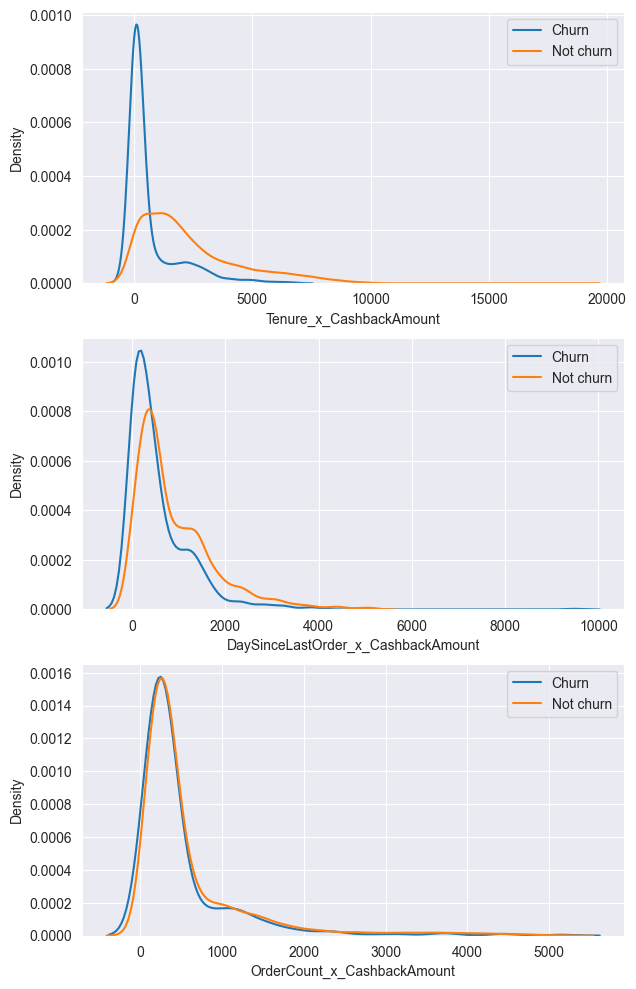

In [86]:
plt.figure(figsize=(7, 12))
plt.subplot(311)
sns.kdeplot(churn.Tenure_x_CashbackAmount, label="Churn")
sns.kdeplot(no_churn.Tenure_x_CashbackAmount, label="Not churn")
plt.xlabel("Tenure_x_CashbackAmount")
plt.legend()

plt.subplot(312)
sns.kdeplot(churn.DaySinceLastOrder_x_CashbackAmount, label="Churn")
sns.kdeplot(no_churn.DaySinceLastOrder_x_CashbackAmount, label="Not churn")
plt.xlabel("DaySinceLastOrder_x_CashbackAmount")
plt.legend()

plt.subplot(313)
sns.kdeplot(churn.OrderCount_x_CashbackAmount, label="Churn")
sns.kdeplot(no_churn.OrderCount_x_CashbackAmount, label="Not churn")
plt.xlabel("OrderCount_x_CashbackAmount")
plt.legend()

In [ ]:
zzz = df[["Tenure", "Tenure_x_CashbackAmount", "CashbackAmount"]].dropna()
pearsonr(zzz.Tenure, zzz.Tenure_x_CashbackAmount), pearsonr(
    zzz.Tenure_x_CashbackAmount, zzz.CashbackAmount
)

(PearsonRResult(statistic=np.float64(0.9257023473473737), pvalue=np.float64(0.0)),
 PearsonRResult(statistic=np.float64(0.7219722253101187), pvalue=np.float64(0.0)))

Only Tenure_x_CashbackAmount and DaySinceLastOrder_x_CashbackAmount seem useful to Churn prediction. The other interactions are noise.

In [64]:
df.isna().sum()

Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
Tenure_group                   264
dtype: int64

In [65]:
categorical_variables

['Churn',
 'PreferredLoginDevice',
 'CityTier',
 'PreferredPaymentMode',
 'Gender',
 'NumberOfDeviceRegistered',
 'PreferedOrderCat',
 'SatisfactionScore',
 'MaritalStatus',
 'NumberOfAddress',
 'Complain']

### Preparing Data for Model Building

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()

In [ ]:
def data_preparation(file_path: str, is_excel: bool = False, sheet_name: bool = None):
    df = (
        pd.read_csv(file_path)
        if not is_excel
        else pd.read_excel(file_path, sheet_name=sheet_name)
    )

    df.drop(["CustomerID"], axis=1, inplace=True)
    df.Tenure = df.Tenure.apply(lambda x: (x // 12) + 1)

    df.PreferredLoginDevice = df.PreferredLoginDevice.replace({"Mobile Phone": "Phone"})
    df.PreferredPaymentMode = df.PreferredPaymentMode.replace(
        {"Cash on Delivery": "COD", "CC": "Credit Card"}
    )
    df.PreferedOrderCat = df.PreferedOrderCat.replace({"Mobile Phone": "Mobile"})

    # To handle correlation
    df["Tenure_Cashback"] = df.Tenure * df.CashbackAmount
    df.drop(["Tenure", "CashbackAmount"], axis=1, inplace=True)

    df[
        [
            "PreferredLoginDevice",
            "PreferredPaymentMode",
            "Gender",
            "PreferedOrderCat",
            "MaritalStatus",
        ]
    ] = encoder.fit_transform(
        df[
            [
                "PreferredLoginDevice",
                "PreferredPaymentMode",
                "Gender",
                "PreferedOrderCat",
                "MaritalStatus",
            ]
        ]
    )

    return df